Azure usage shape: (1080, 6)
External factors shape: (90, 4)
Merged dataset shape: (1080, 9)


,date,region,resource_type,usage_cpu,usage_storage,users_active,economic_index,cloud_market_demand,holiday
0,2023-01-01,East US,VM,88,1959,470,104.97,0.99,1
1,2023-01-01,East US,Storage,92,1595,388,104.97,0.99,1
2,2023-01-01,East US,Container,70,621,414,104.97,0.99,1
3,2023-01-01,West US,VM,60,1982,287,104.97,0.99,1
4,2023-01-01,West US,Storage,85,1371,351,104.97,0.99,1


Missing values after merge:
 date                   0
region                 0
resource_type          0
usage_cpu              0
usage_storage          0
users_active           0
economic_index         0
cloud_market_demand    0
holiday                0
dtype: int64
✅ Cleaned dataset saved at ../data/processed/cleaned_merged.csv


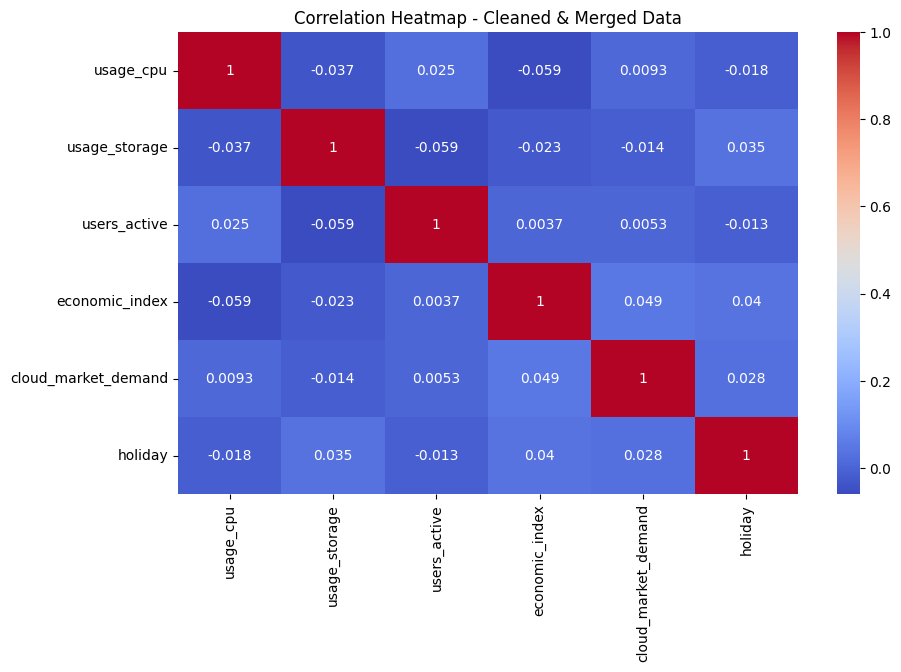

In [1]:
# 📌 Notebook 02: Data Cleaning & Merging

# Step 1: Import libraries
import pandas as pd

# Step 2: Load raw datasets
azure_df = pd.read_csv("../data/raw/azure_usage.csv")
external_df = pd.read_csv("../data/raw/external_factors.csv")

print("Azure usage shape:", azure_df.shape)
print("External factors shape:", external_df.shape)

# Step 3: Handle missing values (forward fill)
azure_df = azure_df.ffill()
external_df = external_df.ffill()

# Step 4: Convert date columns
azure_df['date'] = pd.to_datetime(azure_df['date'])
external_df['date'] = pd.to_datetime(external_df['date'])

# Step 5: Merge datasets on date
merged_df = pd.merge(azure_df, external_df, on="date", how="left")

print("Merged dataset shape:", merged_df.shape)
display(merged_df.head())

# Step 6: Data quality check
print("Missing values after merge:\n", merged_df.isnull().sum())

# Step 7: Save processed dataset
merged_df.to_csv("../data/processed/cleaned_merged.csv", index=False)
print("✅ Cleaned dataset saved at ../data/processed/cleaned_merged.csv")

# Step 8: Quick correlation check on merged data (numeric only)
numeric_df = merged_df.select_dtypes(include=['number'])

if not numeric_df.empty:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(10,6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap - Cleaned & Merged Data")
    plt.show()
else:
    print("No numeric columns in merged dataset for correlation heatmap.")
